# SHAP Explainability - Credit Card Fraud Detection

This notebook loads the already-trained XGBoost model (from `creditcardfrauddetection.ipynb`) and explains its predictions using SHAP, instead of retraining anything.

In [1]:
import pandas as pd
import joblib
import shap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


## Load the saved model, scaler, and rebuild the same train/test split

Using `scaler.transform` (not `fit_transform`) since the scaler was already fit during training.

In [11]:
# Load the saved model and scaler instead of retraining
xgb_model = joblib.load('xgb_fraud_model.pkl')
scaler = joblib.load('scaler.pkl')

# Reload and re-split the data the same way as training, so X_test matches
df = pd.read_csv('creditcard.csv')
X = df.drop(columns=['Class'])
y = df['Class']

# The loaded scaler was not fitted on 'Time', so this line causes an error.
# X['Time'] = scaler.transform(X[['Time']])
X['Amount'] = scaler.transform(X[['Amount']])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('X_test shape:', X_test.shape)


X_test shape: (56962, 30)


## Step 1: Create the SHAP explainer and calculate SHAP values

`TreeExplainer` is built specifically for tree-based models like XGBoost - fast and exact for this model type.

In [12]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

print('SHAP values shape:', shap_values.shape)

SHAP values shape: (56962, 30)


## Step 2: Which features matter most overall?

Ranked bar chart - which of V1-V28, Time, Amount push predictions toward fraud most, on average.

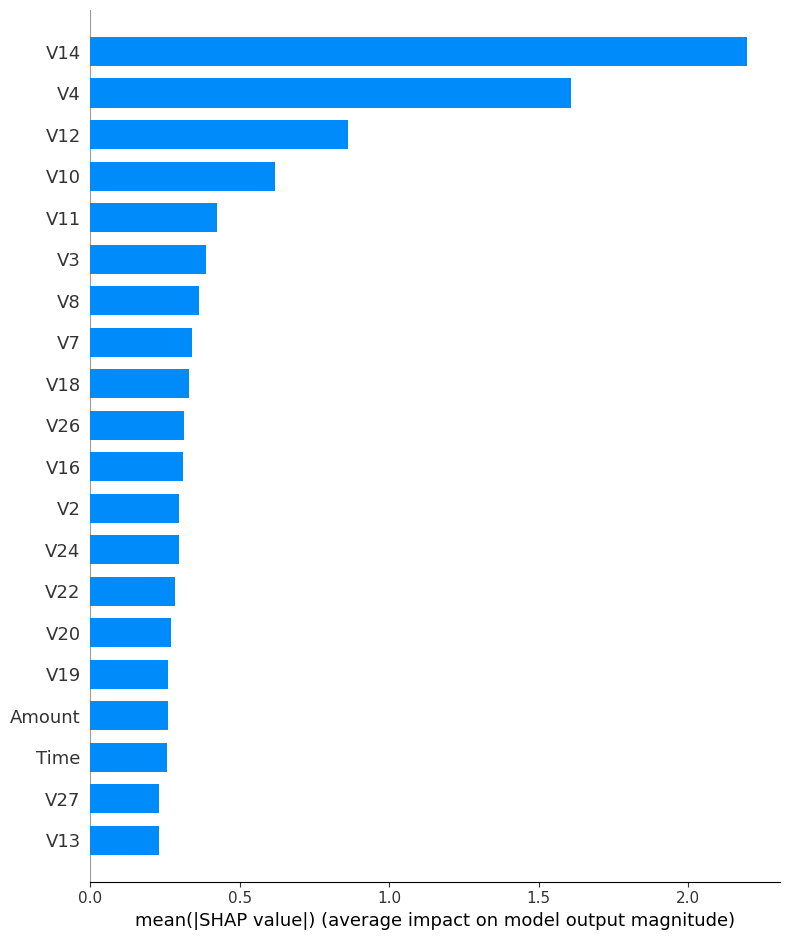

In [13]:
shap.summary_plot(shap_values, X_test, plot_type='bar')

## Step 3: Full picture - direction + magnitude

Dot-plot version: shows not just *which* features matter, but *how* (e.g. high V14 pushes toward fraud, low V14 pushes toward normal).

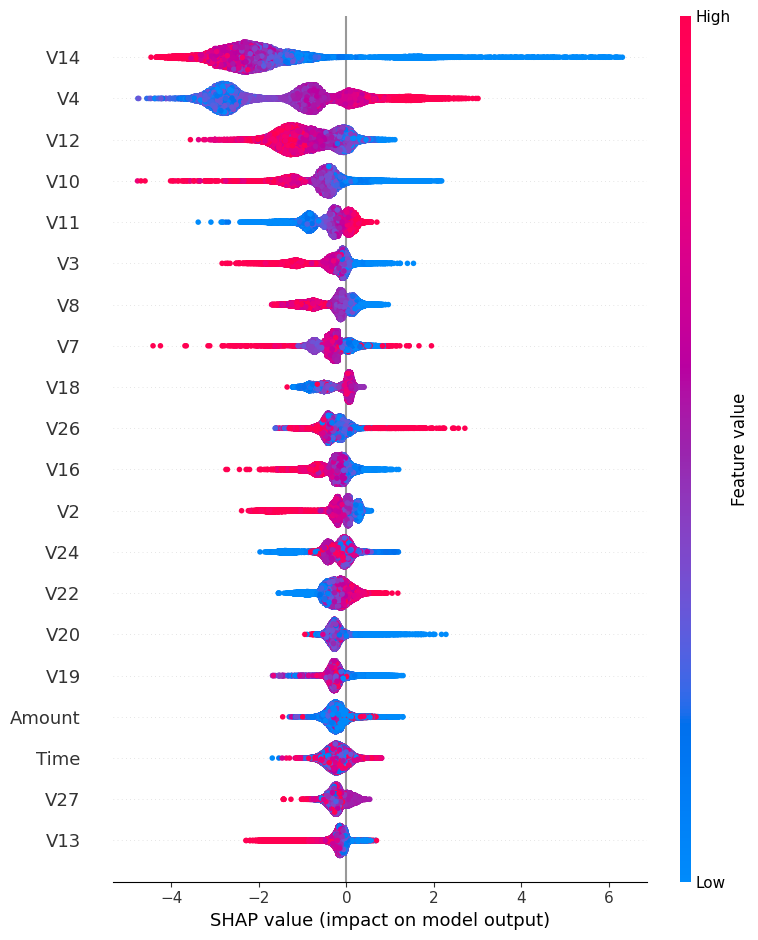

In [14]:
shap.summary_plot(shap_values, X_test)

## Step 4: Explain one single fraud prediction

This is what powers the dashboard's 'why was this flagged' explanation.

In [15]:
# Pick one fraud transaction from the test set
idx = y_test[y_test == 1].index[0]
sample = X_test.loc[[idx]]

shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[X_test.index.get_loc(idx)],
    sample
)

## Step 5: Top 5 contributing features for that transaction (plain list, dashboard-ready format)

In [16]:
row_shap = shap_values[X_test.index.get_loc(idx)]
feature_names = X_test.columns.tolist()

top_features = sorted(zip(feature_names, row_shap), key=lambda x: abs(x[1]), reverse=True)[:5]

print(f'Transaction #{idx} - Top 5 features driving this prediction:')
for feature, impact in top_features:
    direction = '→ pushes toward FRAUD' if impact > 0 else '→ pushes toward NORMAL'
    print(f'  {feature}: {impact:.4f}  {direction}')

Transaction #77348 - Top 5 features driving this prediction:
  V14: 6.0517  → pushes toward FRAUD
  V10: 2.0713  → pushes toward FRAUD
  V17: 0.9566  → pushes toward FRAUD
  V12: 0.8359  → pushes toward FRAUD
  V7: 0.7500  → pushes toward FRAUD
